x# 주제 : 미국의 대통령은 어떻게 뽑힐까?

## 데이터 소개
- 이번 주제는 US Election 2020 데이터셋을 사용합니다.

- 총 11개의 파일 중 정보가 가장 많은 2개의 파일을 사용합니다.
president_county_candidate.csv: 대통령 투표 결과
governors_county_candidate.csv: 카운티 지사 투표 결과

- 총 1개의 보조 데이터를 이용합니다.
acs2017_county_data.csv: 카운티별 인구조사 데이터

- 각 파일의 컬럼은 아래와 같습니다.   
state: 주   
county: 카운티(군)   
district: 지구    
candidate: 후보자   
party: 후보자의 소속 정당   
total_votes: 득표 수   
won: 지역 투표 우승 여부



데이터 출처: https://www.kaggle.com/unanimad/us-election-2020   
보조 데이터: https://www.kaggle.com/muonneutrino/us-census-demographic-data

## 최종 목표
- 보조 데이터셋을 이용하여 데이터셋 보강하는 방법 이해
- plotly를 이용한 Choropleth 시각화 방법 이해
- Regression과 Classification의 차이 이해

출제자 : 신제용 강사

## Step 0. 데이터에 관한 사전 배경 지식
- 미국의 선거 제도에 대하여
- 2020 미국 선거 데이터셋 설명
- 2017 미국 인구조사 데이터셋(보조 데이터셋) 설명

## Step 1. 데이터셋 준비하기

In [ ]:
# !pip install geopandas
# !pip install pyshp
# !pip install shapely
# !pip install plotly-geo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import geopandas
# import pyshp
# import shapely
# import plotly

### 문제 1. Colab Notebook에 Kaggle API 세팅하기

In [ ]:
import os
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기

In [ ]:
os.environ['KAGGLE_USERNAME'] = 'fastcampuskim'
os.environ['KAGGLE_KEY'] = 'c939a1e37f5ca93b6406a66fc8bb08e5'

### 문제 2. 데이터 다운로드 및 압축 해제하기

In [ ]:
!kaggle datasets download -d unanimad/us-election-2020
!kaggle datasets download -d muonneutrino/us-census-demographic-data
!unzip '*.zip'

us-election-2020.zip: Skipping, found more recently modified local copy (use --force to force download)
us-census-demographic-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  us-census-demographic-data.zip
replace acs2015_census_tract_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: acs2015_census_tract_data.csv  
  inflating: acs2015_county_data.csv  
  inflating: acs2017_census_tract_data.csv  
  inflating: acs2017_county_data.csv  

Archive:  us-election-2020.zip
  inflating: governors_county.csv    
  inflating: governors_county_candidate.csv  
  inflating: governors_state.csv     
  inflating: house_candidate.csv     
  inflating: house_state.csv         
  inflating: president_county.csv    
  inflating: president_county_candidate.csv  
  inflating: president_state.csv     
  inflating: senate_county.csv       
  inflating: senate_county_candidate.csv  
  inflating: senate_state.csv        

2 archives were succes

### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기

In [ ]:
# from US Election 2020
df_pres = pd.read_csv('president_county_candidate.csv')
df_gov = pd.read_csv('governors_county_candidate.csv')

# from US Census 2017
df_census = pd.read_csv('acs2017_county_data.csv')

In [ ]:
# State Code 관련 부가 자료
state_code = pd.read_html('https://www.infoplease.com/us/postal-information/state-abbreviations-and-state-postal-codes')[0]

##Step 2. EDA 및 데이터 기초 통계 분석

### 문제 4. 데이터프레임의 각 컬럼 분석하기

In [ ]:
df_pres.head() # 주별 대통령 선거 후보 투표 데이터

,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


In [ ]:
df_pres['candidate'].unique()

array(['Joe Biden', 'Donald Trump', 'Jo Jorgensen', 'Howie Hawkins',
       ' Write-ins', 'Gloria La Riva', 'Brock Pierce',
       'Rocky De La Fuente', 'Don Blankenship', 'Kanye West',
       'Brian Carroll', 'Ricki Sue King', 'Jade Simmons',
       'President Boddie', 'Bill Hammons', 'Tom Hoefling',
       'Alyson Kennedy', 'Jerome Segal', 'Phil Collins',
       ' None of these candidates', 'Sheila Samm Tittle', 'Dario Hunter',
       'Joe McHugh', 'Christopher LaFontaine', 'Keith McCormic',
       'Brooke Paige', 'Gary Swing', 'Richard Duncan', 'Blake Huber',
       'Kyle Kopitke', 'Zachary Scalf', 'Jesse Ventura', 'Connie Gammon',
       'John Richard Myers', 'Mark Charles', 'Princess Jacob-Fambro',
       'Joseph Kishore', 'Jordan Scott'], dtype=object)

In [ ]:
df_gov.head() # 주별 주지사 후보 투표 데이터

,state,county,candidate,party,votes,won
0,Delaware,Kent County,John Carney,DEM,44352,True
1,Delaware,Kent County,Julianne Murray,REP,39332,False
2,Delaware,Kent County,Kathy DeMatteis,IPD,1115,False
3,Delaware,Kent County,John Machurek,LIB,616,False
4,Delaware,New Castle County,John Carney,DEM,191678,True


In [ ]:
df_census.head() # 주별 census(인구조사) 데이터

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,0.6,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,0.8,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,2.2,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,0.3,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9


In [ ]:
df_census['County'].value_counts()

Washington County    30
Jefferson County     25
Franklin County      24
Jackson County       23
Lincoln County       23
                     ..
Nantucket County      1
Hampden County        1
Dukes County          1
Berkshire County      1
Yauco Municipio       1
Name: County, Length: 1955, dtype: int64

In [ ]:
state_code.head()

,State Name/District,Postal Abbreviation,Postal Code
0,Alabama,Ala.,AL
1,Alaska,Alaska,AK
2,Arizona,Ariz.,AZ
3,Arkansas,Ark.,AR
4,California,Calif.,CA


### 문제 5. County 별 통계로 데이터프레임 구조 변경하기

In [ ]:
# 대통령선거 - DEM, REP 정당 별 주와 county의 총 투표 수 
data = df_pres.loc[df_pres['party'].apply(lambda s: str(s) in ['DEM','REP'])]
table_pres = pd.pivot_table(data=data, index=['state','county'], columns='party', values='total_votes')
table_pres.rename({'DEM':'Pres_DEM','REP':'Pres_REP'}, axis=1, inplace=True)

In [ ]:
# 주지사 선거 - DEM, REP 정당 별 주와 county의 총 투표 수 
data = df_gov.loc[df_gov['party'].apply(lambda s: str(s) in ['DEM','REP'])]
table_gov = pd.pivot_table(data=data, index=['state','county'], columns='party', values='votes')
table_gov.rename({'DEM':'Gov_DEM','REP':'Gov_REP'}, axis=1, inplace=True)

In [ ]:
# 인구조사 데이터
df_census.rename({'State':'state','County':'county'}, axis=1, inplace=True)
df_census.drop('CountyId', axis=1, inplace=True)
df_census.set_index(['state','county'], inplace=True)
df_census.head()

TotalPop    Men   Women  Hispanic  White  Black  \
state   county                                                            
Alabama Autauga County     55036  26899   28137       2.7   75.4   18.9   
        Baldwin County    203360  99527  103833       4.4   83.1    9.5   
        Barbour County     26201  13976   12225       4.2   45.7   47.8   
        Bibb County        22580  12251   10329       2.4   74.6   22.0   
        Blount County      57667  28490   29177       9.0   87.4    1.5   

                        Native  Asian  Pacific  VotingAgeCitizen  ...  Walk  \
state   county                                                    ...         
Alabama Autauga County     0.3    0.9      0.0             41016  ...   0.6   
        Baldwin County     0.8    0.7      0.0            155376  ...   0.8   
        Barbour County     0.2    0.6      0.0             20269  ...   2.2   
        Bibb County        0.4    0.0      0.0             17662  ...   0.3   
        Blount County      0.3    0.1      0.0             42513  ...   0.4   

                        OtherTransp  WorkAtHome  MeanCommute  Employed  \
state   county                                                           
Alabama Autauga County          1.3         2.5         25.8     24112   
        Baldwin County          1.1         5.6         27.0     89527   
        Barbour County          1.7         1.3         23.4      8878   
        Bibb County             1.7         1.5         30.0      8171   
        Blount County           0.4         2.1         35.0     21380   

                        PrivateWork  PublicWork  SelfEmployed  FamilyWork  \
state   county                                                              
Alabama Autauga County         74.1        20.2           5.6         0.1   
        Baldwin County         80.7        12.9           6.3         0.1   
        Barbour County         74.1        19.1           6.5         0.3   
        Bibb County            76.0        17.4           6.3         0.3   
        Blount County          83.9        11.9           4.0         0.1   

                        Unemployment  
state   county                        
Alabama Autauga County           5.2  
        Baldwin County           5.5  
        Barbour County          12.4  
        Bibb County              8.2  
        Blount County            4.9  

[5 rows x 34 columns]

In [ ]:
df_census.drop(['Income', 'IncomeErr', 'IncomePerCapErr'], axis=1, inplace=True) # 필요없는 컬럼 삭제
df_census.drop('Women', axis=1, inplace=True) # 여성 데이터 삭제 (총 인구수-남성=여성 이니까?)
df_census['Men'] /= df_census['TotalPop'] # 비율로 변환
df_census['VotingAgeCitizen'] /= df_census['TotalPop']
df_census['Employed'] /= df_census['TotalPop'] 
df_census.head()

TotalPop       Men  Hispanic  White  Black  Native  \
state   county                                                               
Alabama Autauga County     55036  0.488753       2.7   75.4   18.9     0.3   
        Baldwin County    203360  0.489413       4.4   83.1    9.5     0.8   
        Barbour County     26201  0.533415       4.2   45.7   47.8     0.2   
        Bibb County        22580  0.542560       2.4   74.6   22.0     0.4   
        Blount County      57667  0.494043       9.0   87.4    1.5     0.3   

                        Asian  Pacific  VotingAgeCitizen  IncomePerCap  ...  \
state   county                                                          ...   
Alabama Autauga County    0.9      0.0          0.745258         27824  ...   
        Baldwin County    0.7      0.0          0.764044         29364  ...   
        Barbour County    0.6      0.0          0.773596         17561  ...   
        Bibb County       0.0      0.0          0.782197         20911  ...   
        Blount County     0.1      0.0          0.737215         22021  ...   

                        Walk  OtherTransp  WorkAtHome  MeanCommute  Employed  \
state   county                                                                 
Alabama Autauga County   0.6          1.3         2.5         25.8  0.438113   
        Baldwin County   0.8          1.1         5.6         27.0  0.440239   
        Barbour County   2.2          1.7         1.3         23.4  0.338842   
        Bibb County      0.3          1.7         1.5         30.0  0.361869   
        Blount County    0.4          0.4         2.1         35.0  0.370749   

                        PrivateWork  PublicWork  SelfEmployed  FamilyWork  \
state   county                                                              
Alabama Autauga County         74.1        20.2           5.6         0.1   
        Baldwin County         80.7        12.9           6.3         0.1   
        Barbour County         74.1        19.1           6.5         0.3   
        Bibb County            76.0        17.4           6.3         0.3   
        Blount County          83.9        11.9           4.0         0.1   

                        Unemployment  
state   county                        
Alabama Autauga County           5.2  
        Baldwin County           5.5  
        Barbour County          12.4  
        Bibb County              8.2  
        Blount County            4.9  

[5 rows x 30 columns]

### 문제 6. 여러 데이터프레임을 하나의 데이터프레임으로 결합하기

In [ ]:
df = pd.concat([table_pres, table_gov, df_census], axis=1) 

### 문제 7. 컬럼간의 Correlation을 Heatmap으로 표현하기

<Axes: >

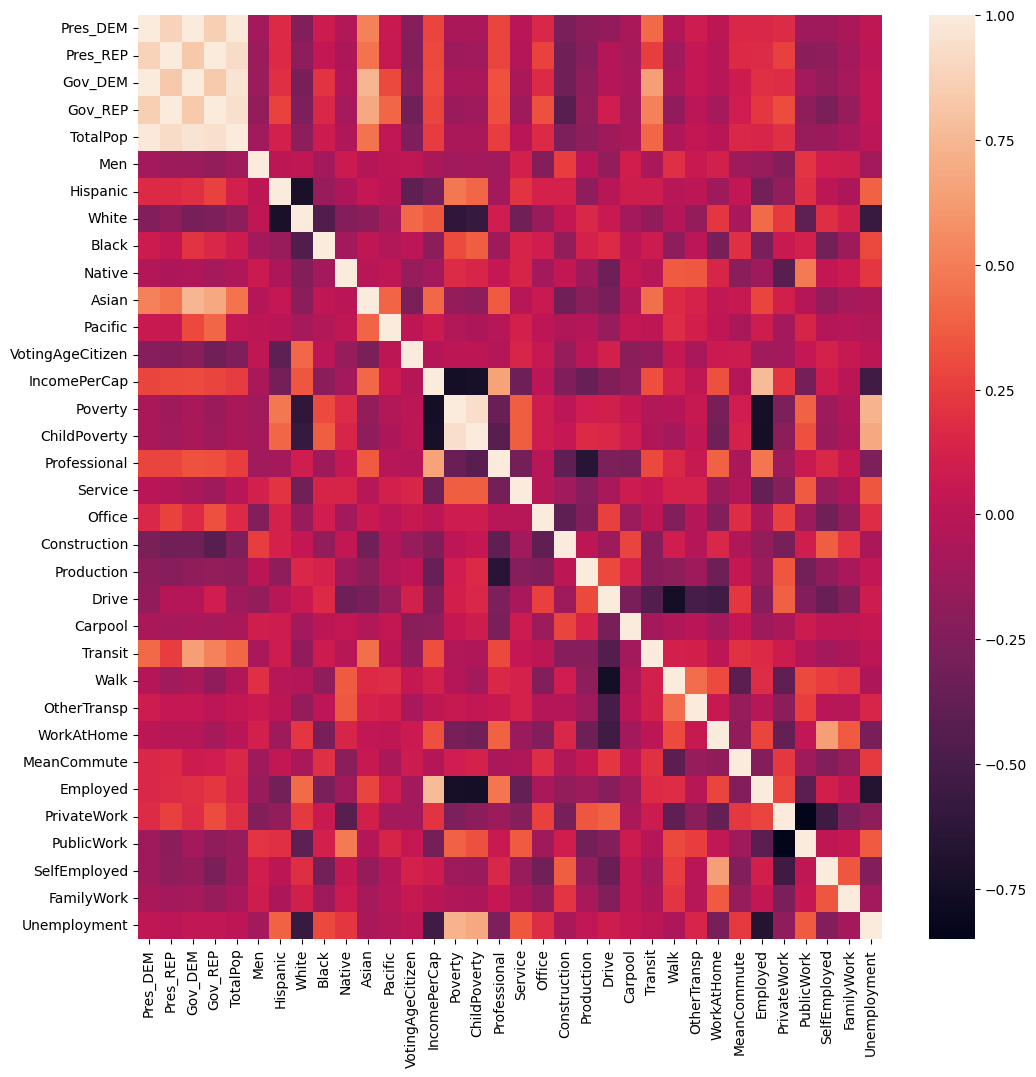

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr())

In [ ]:
df['Pres_DEM'].unique()

array([ 7503., 24578.,  4816., ...,  1591.,   360.,    nan])

<Axes: >

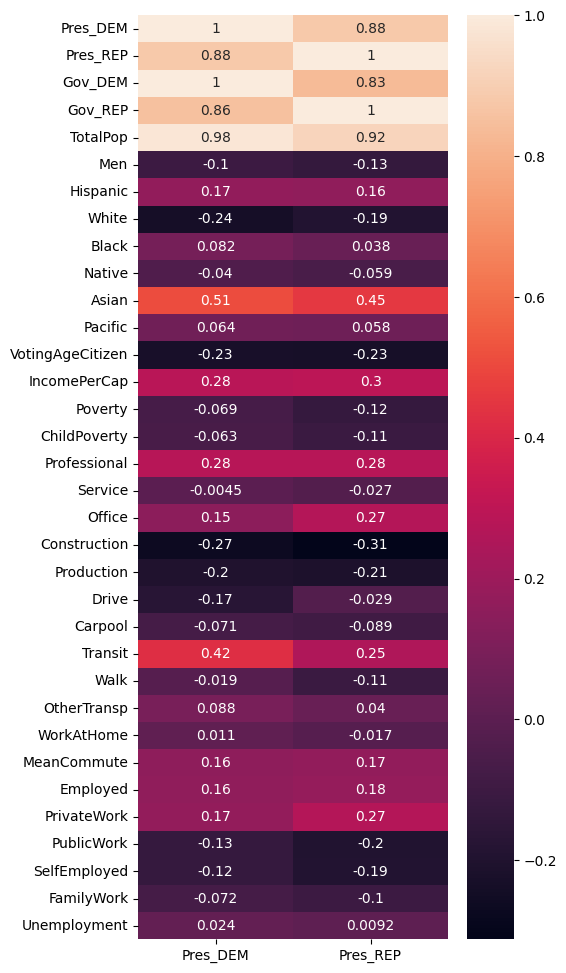

In [ ]:
plt.figure(figsize=(5,12))
sns.heatmap(df.corr()[['Pres_DEM','Pres_REP']], annot=True)
# 민주당과 공화당 투표수에 대한 상관계수

<Axes: >

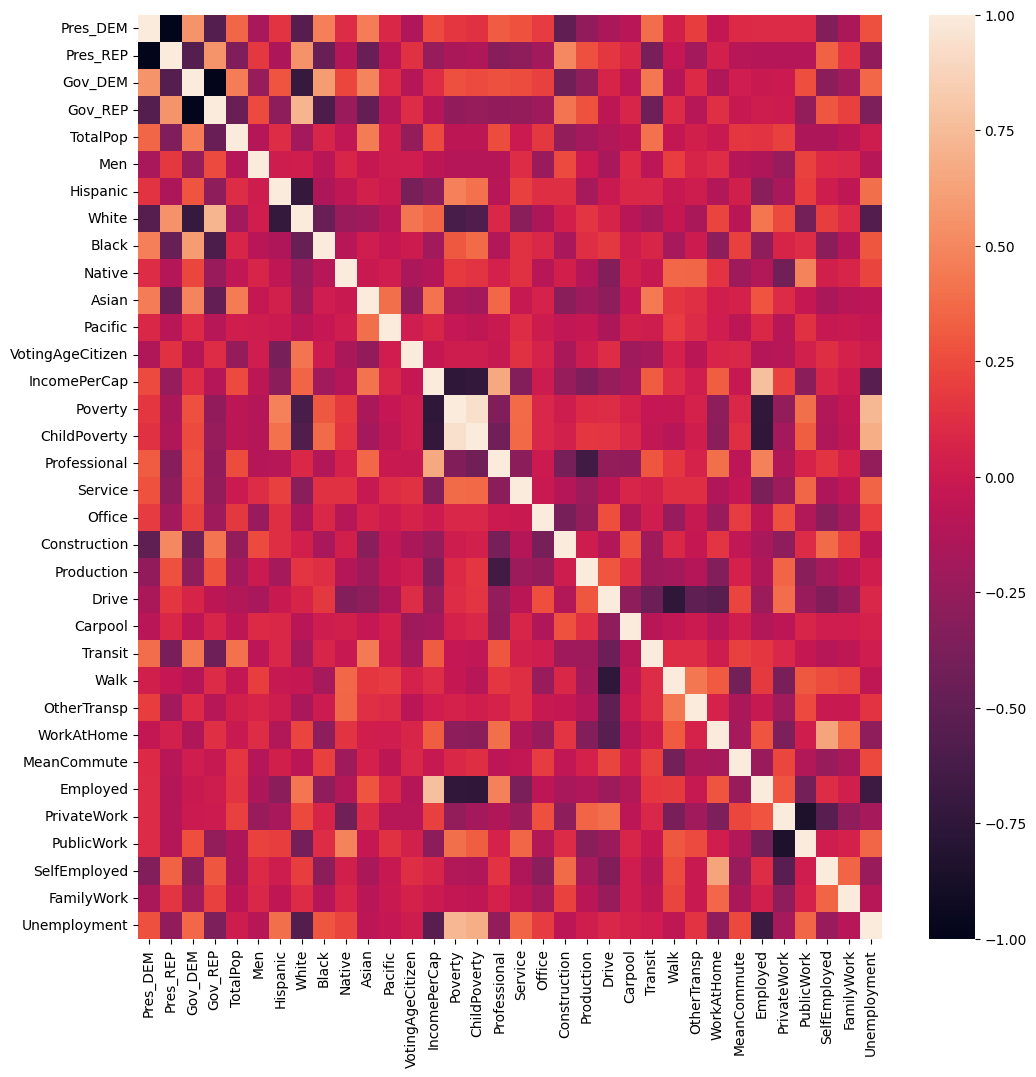

In [ ]:
# 비율로 변환 후 상관계수 시각화
df_norm = df.copy()
df_norm['Pres_DEM'] /= df['Pres_DEM'] + df['Pres_REP']
df_norm['Pres_REP'] /= df['Pres_DEM'] + df['Pres_REP']
df_norm['Gov_DEM'] /= df['Gov_DEM'] + df['Gov_REP']
df_norm['Gov_REP'] /= df['Gov_DEM'] + df['Gov_REP']
# normalize된 데이터로 다시 correation 확인
plt.figure(figsize=(12, 12))
sns.heatmap(df_norm.corr())
# -1 ~ 1 사이로 변환됨.

<Axes: >

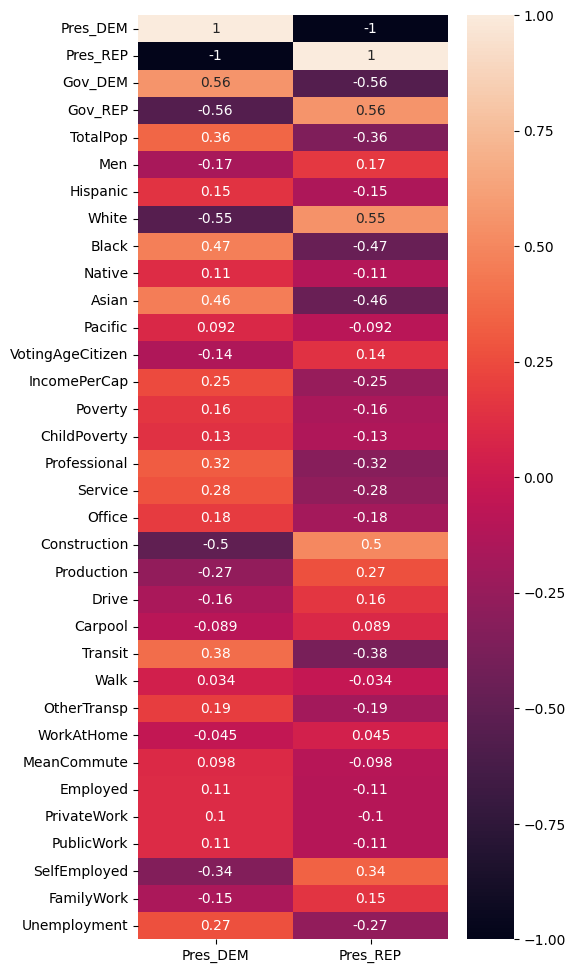

In [ ]:
plt.figure(figsize=(5,12))
sns.heatmap(df_norm.corr()[['Pres_DEM','Pres_REP']], annot=True)

### 문제 8. Seaborn을 이용하여 연관성 높은 데이터의 Jointplot 확인

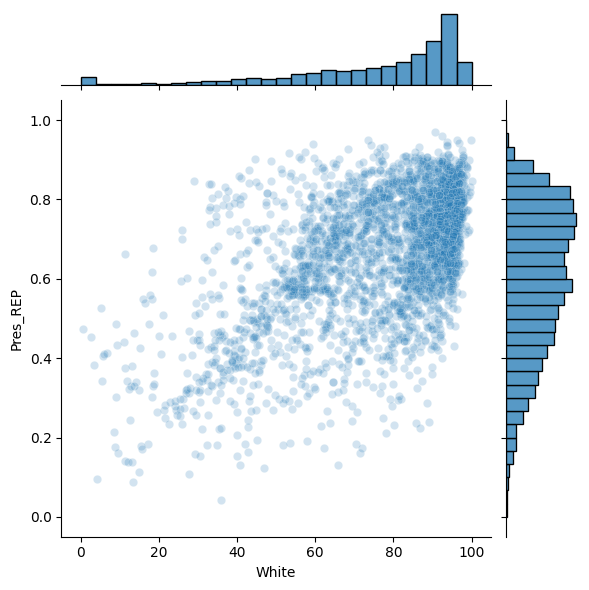

In [ ]:
sns.jointplot(x='White', y='Pres_REP', data=df_norm, alpha=0.2)
# 주별 백인 비율과 대통령선거 공화당 투표율 간에 양의 상관관계가 있음

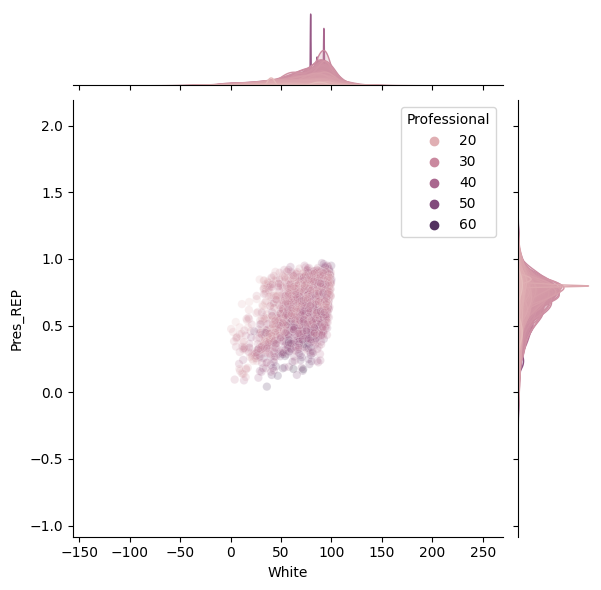

In [ ]:
sns.jointplot(x='White', y='Pres_REP', hue='Professional', data=df_norm, alpha=0.2)
plt.show()
# 전문직 비율 ? 

In [ ]:
df_norm.Black.describe() # 평균적으로 5%

count    542.000000
mean       5.493173
std       10.631283
min        0.000000
25%        0.300000
50%        1.000000
75%        4.650000
max       61.600000
Name: Black, dtype: float64

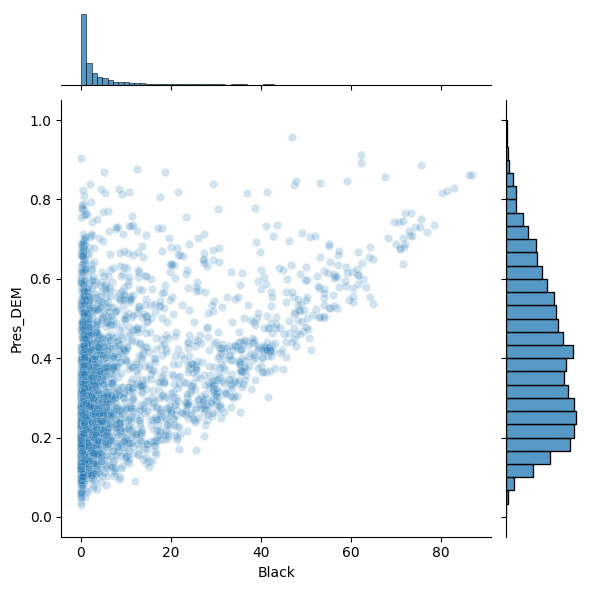

In [ ]:
sns.jointplot(x='Black', y='Pres_DEM', data=df_norm, alpha=0.2)
# 흑인비율이 낮은 곳이 많음

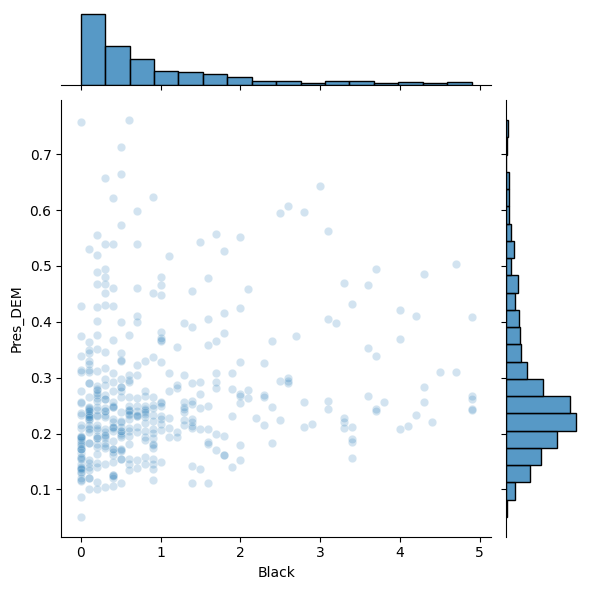

In [ ]:
sns.jointplot(x='Black', y='Pres_DEM', data=df_norm[df_norm['Black']<5], alpha=0.2)
# 흑인 비율이 낮은 경우의 민주당 투표율이 더 높은 경향이 있음

## Step 3. Plotly를 이용하여 데이터 시각화하기

### 문제 9. Plotly의 Choropleth 데이터 포맷으로 맞추기

In [ ]:
import plotly.figure_factory as ff

# FIPS 코드 불러오기
df_sample = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/laucnty16.csv')
df_sample['State FIPS Code'] = df_sample['State FIPS Code'].apply(lambda x: str(x).zfill(2))
df_sample['County FIPS Code'] = df_sample['County FIPS Code'].apply(lambda x: str(x).zfill(3))
df_sample['FIPS'] = df_sample['State FIPS Code'] + df_sample['County FIPS Code']

# Color Scale 세팅
colorscale = ["#f7fbff","#ebf3fb","#deebf7","#d2e3f3","#c6dbef","#b3d2e9","#9ecae1",
              "#85bcdb","#6baed6","#57a0ce","#4292c6","#3082be","#2171b5","#1361a9",
              "#08519c","#0b4083","#08306b"]

In [ ]:
display(df_sample.head())
display(state_code.head())

,LAUS Code,State FIPS Code,County FIPS Code,County Name/State Abbreviation,Year,Labor Force,Employed,Unemployed,Unemployment Rate (%),FIPS
0,CN0100100000000,01,001,"Autauga County, AL",2016,"25,649","24,297","1,352",5.3,01001
1,CN0100300000000,01,003,"Baldwin County, AL",2016,"89,931","85,061","4,870",5.4,01003
2,CN0100500000000,01,005,"Barbour County, AL",2016,"8,302","7,584",718,8.6,01005
3,CN0100700000000,01,007,"Bibb County, AL",2016,"8,573","8,004",569,6.6,01007
4,CN0100900000000,01,009,"Blount County, AL",2016,"24,525","23,171","1,354",5.5,01009


,State Name/District,Postal Abbreviation,Postal Code
0,Alabama,Ala.,AL
1,Alaska,Alaska,AK
2,Arizona,Ariz.,AZ
3,Arkansas,Ark.,AR
4,California,Calif.,CA


In [ ]:
state_map = state_code.set_index('State Name/District')['Postal Code']
counties = df_norm.reset_index()['county'] + ', ' + df_norm.reset_index()['state'].map(state_map)
counties_to_fips = df_sample.set_index('County Name/State Abbreviation')['FIPS']
fips = counties.map(counties_to_fips)

In [ ]:
# ff.create_choropleth()에서 사용할 수 있도록 데이터프레임 정리하기
# Hint) 공식 레퍼런스 참조: https://plotly.com/python/county-choropleth/#the-entire-usa
data = df_norm.reset_index()['Pres_DEM'][fips.notna()]
fips = fips[fips.notna()]

### 문제 10. Choropleth map 시각화하기


In [ ]:
import plotly.figure_factory as ff

In [ ]:
#!pip install shapely==1.7.1

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# ff.create_choropleth() 메소드를 이용하여 Choropleth 플랏하기
# Hint) 공식 레퍼런스 참조: https://plotly.com/python/county-choropleth/#the-entire-usa

fig = ff.create_choropleth(
    fips=fips, values=data,
    show_state_data=False,
    colorscale=colorscale,
    binning_endpoints=list(np.linspace(0.0, 1.0, len(colorscale) - 2)),
    show_hover=True, centroid_marker={'opacity': 0},
    asp=2.9, title='USA by Voting for DEM Presient'
)

fig.layout.template = None
fig.show()

## Step 4. 모델 학습을 위한 데이터 전처리 

### 문제 11. 학습을 위한 데이터프레임 구성하기

In [ ]:
# 투표 결과에 해당하는 데이터는 입력 데이터에서 제거한다.
# 예측 타겟은 DEM vs. REP 투표 비율로 한다.
df_norm.dropna(inplace=True)
X = df_norm.drop(['Pres_DEM', 'Pres_REP', 'Gov_DEM', 'Gov_REP'], axis=1)
y = df_norm['Pres_DEM']

### 문제 12. StandardScaler를 이용해 수치형 데이터 표준화하기

In [ ]:
from sklearn.preprocessing import StandardScaler
# StandardScaler를 이용해 수치형 데이터를 표준화하기
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X = pd.DataFrame(data=X_scaled, index=X.index, columns=X.columns)
X.head()

TotalPop       Men  Hispanic     White     Black  \
state    county                                                                
Delaware Kent County        0.651462 -0.946145  0.346057 -1.423723  1.751813   
         New Castle County  3.043033 -0.848175  0.828313 -1.695454  1.751813   
         Sussex County      0.917027 -0.818852  0.759420 -0.634409  0.622026   
Indiana  Adams County      -0.213551 -0.230718 -0.067305  0.581911 -0.432442   
         Allen County       1.870146 -0.656809  0.414951 -0.653818  0.546706   

                              Native     Asian   Pacific  VotingAgeCitizen  \
state    county                                                              
Delaware Kent County       -0.191121  0.783427 -0.393531         -0.388638   
         New Castle County -0.239442  3.218819 -0.393531         -0.665857   
         Sussex County     -0.215282  0.210394 -0.393531          0.227859   
Indiana  Adams County      -0.263602 -0.362639 -0.393531         -1.625095   
         Allen County      -0.239442  1.857865 -0.393531         -1.068441   

                            IncomePerCap  ...      Walk  OtherTransp  \
state    county                           ...                          
Delaware Kent County            0.313498  ... -0.455170    -0.337372   
         New Castle County      1.606755  ... -0.301446    -0.337372   
         Sussex County          1.122397  ... -0.506412    -0.141175   
Indiana  Adams County          -0.755470  ... -0.250204     0.447416   
         Allen County           0.224871  ... -0.608895    -0.533569   

                            WorkAtHome  MeanCommute  Employed  PrivateWork  \
state    county                                                              
Delaware Kent County         -0.325794     0.608072  0.209912    -0.063847   
         New Castle County   -0.325794     0.492385  0.801126     1.168959   
         Sussex County        0.055883     0.415259 -0.026356     0.503244   
Indiana  Adams County        -0.244006    -0.066773 -0.205611     0.971710   
         Allen County        -0.380320    -0.355993  0.707837     1.477161   

                            PublicWork  SelfEmployed  FamilyWork  Unemployment  
state    county                                                                 
Delaware Kent County          0.791294     -0.836585   -0.243581      0.265911  
         New Castle County   -0.715528     -0.999491   -0.404976      0.192397  
         Sussex County       -0.251891     -0.470046   -0.404976      0.045370  
Indiana  Adams County        -1.344751     -0.001691    0.401999     -0.285443  
         Allen County        -1.278517     -0.816222   -0.404976      0.118884  

[5 rows x 30 columns]

### 문제 13. 학습데이터와 테스트데이터 분리하기

In [ ]:
from sklearn.model_selection import train_test_split
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### 문제 14. PCA를 이용해 데이터 전처리 수행하기

- 전체 데이터(독립변수들)의 분산을 가장 잘 설명하는 축의 개수를 선정해 그 축에 따라 변형된 데이터를 배열하면 그 데이터가 주성분이 됨.
- 변수의 개수가 너무 많은 경우 이들 중 중요하다고 판단되는 변수 몇 개만 뽑아 모델링할 시 사용
- 데이터의 스케일에 따라 주성분의 설명가능한 분산량이 
달라질 수 있기 때문에 반드시 표준화를 해주어야함.

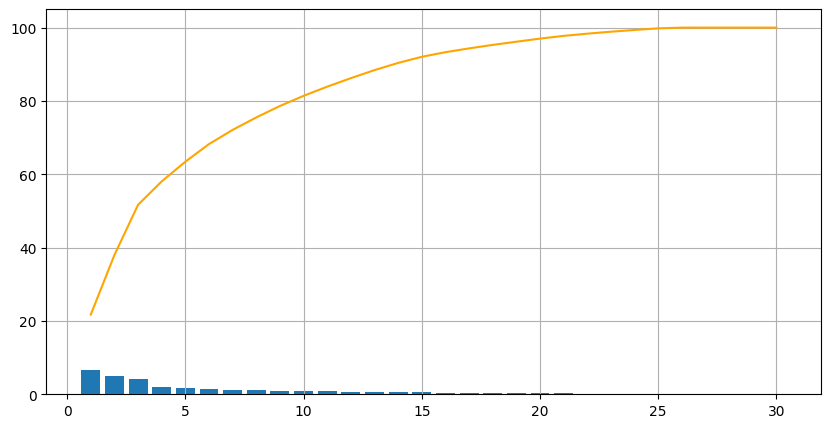

In [ ]:
from sklearn.decomposition import PCA

# PCA를 이용해 Dimensionality Reduction 수행하기
pca = PCA()
pca.fit(X_train)
exp_val_cumul = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10,5))
plt.plot(range(1, len(pca.explained_variance_) + 1), exp_val_cumul*100, color='orange')
plt.bar(range(1, len(pca.explained_variance_) + 1), pca.explained_variance_)
plt.grid()
# 30개 중 10개의 변수만 있어도 전체 데이터의 약 80% 설명할 수 있음

**주성분 개수 결정**
1. elbow point(곡선의 기울기가 급격히 감소하는 지점)
2. kaiser's rule ( 고유값 1이상의 주성분들)
3. 누적설명률이 70-80%이상인 지점

## Step 4. Regression 모델 학습하기

### 문제 15. LightGBM Regression 모델 학습하기

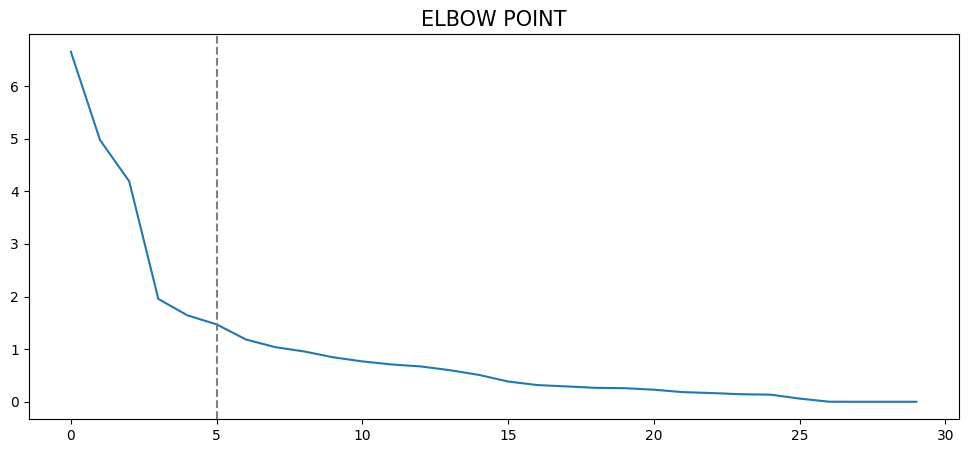

In [ ]:
# elbow point 확인
plt.figure(figsize=(12, 5))
plt.plot(range(0, 30), np.sort(pca.explained_variance_)[::-1][0:30])

plt.title('ELBOW POINT', size=15)
plt.axvline(5, ls='--', color='grey')

plt.show()
# 상위 5개의 eigen value를 제외한 나머지는 큰 차이가 없어보임 

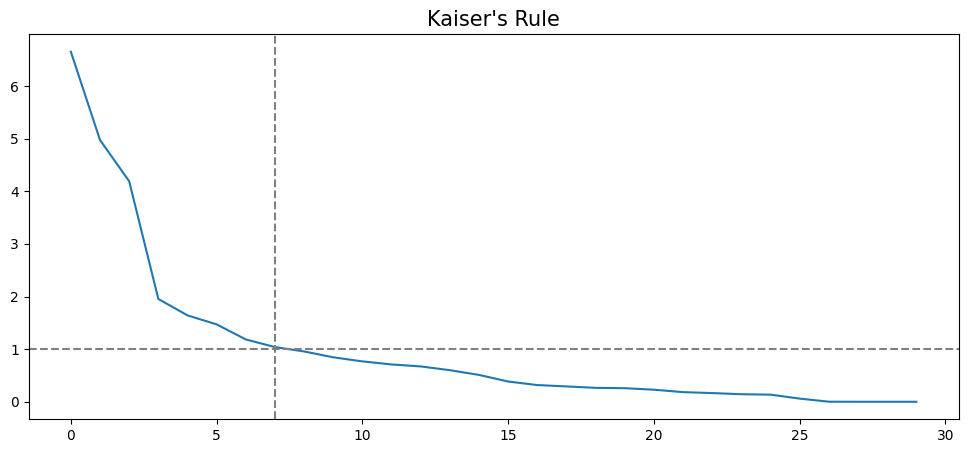

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(range(0, 30), np.sort(pca.explained_variance_)[::-1][0:30])

plt.title("Kaiser's Rule", size=15)
plt.axhline(1, ls='--', color='grey')
plt.axvline(7, ls='--', color='grey')

plt.show()
# 7개의 주성분 사용 시 eigen value가 모두 1 이상임

In [ ]:
pca = PCA(n_components=7)
pca.fit(X)
X_pca_train = pca.transform(X_train)
X_pca_test  = pca.transform(X_test)

In [ ]:
from lightgbm import LGBMRegressor
# LGBMRegressor 모델 생성/학습. Feature에 PCA 적용하기
model_reg = LGBMRegressor()
model_reg.fit(X_train, y_train)

model_reg_pca = LGBMRegressor()
model_reg_pca.fit(X_pca_train, y_train)

LGBMRegressor()

### 문제 16. Regression 모델 정확도 출력하기

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report
from math import sqrt
# Predict를 수행하고 mean_absolute_error, rmse, classification_report 결과 출력하기
pred_pca = model_reg_pca.predict(X_pca_test)
pred = model_reg.predict(X_test)
print('LGBM: ',mean_absolute_error(y_test, pred),'    LGBM_PCA: ',mean_absolute_error(y_test, pred_pca))
print('LGBM: ', sqrt(mean_squared_error(y_test, pred)),'        LGBM_PCA: ',sqrt(mean_squared_error(y_test, pred_pca)))
# print(classification_report(y_test > 0.5, pred > 0.5))

# PCA 진행 시 모델의 정확도가 증가한 것을 확인할 수 있다.

LGBM:  0.053261679672733014     LGBM_PCA:  0.06295098721657102
LGBM:  0.07527410114651         LGBM_PCA:  0.08377286006547821


## Step 5. Classification 모델 학습하기

### 문제 17. XGBoost 모델 생성/학습하기

In [ ]:
y_train > 0.5

state          county           
Utah           Sanpete County       False
Indiana        Tippecanoe County     True
North Dakota   Eddy County          False
West Virginia  Randolph County      False
Missouri       Chariton County      False
                                    ...  
               Dunklin County       False
               Jefferson County     False
Indiana        Rush County          False
Montana        Liberty County       False
Indiana        Huntington County    False
Name: Pres_DEM, Length: 379, dtype: bool

In [ ]:
from xgboost import XGBClassifier
# XGBClassifier 모델 생성/학습
model_cls = XGBClassifier()
model_cls.fit(X_train, y_train > 0.5) # 투표율이 0,5 초과인 경우 True, 0.5 이하인 경우 False

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

###문제 18. Classifier의 Feature Importance 시각화하기

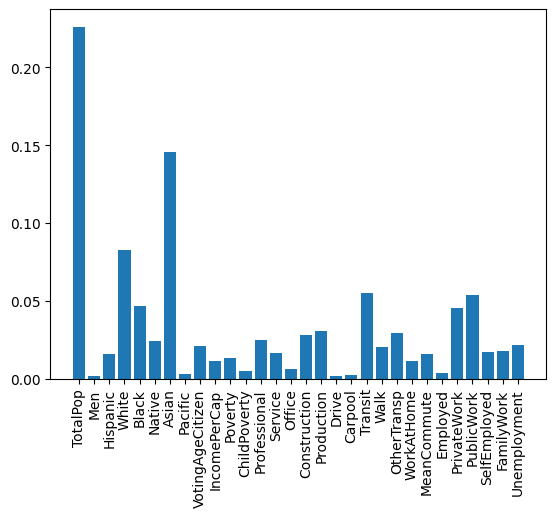

In [ ]:
# XGBClassifier 모델의 feature_importances_ 속성 시각화
plt.bar(X.columns, model_cls.feature_importances_)
plt.xticks(rotation=90)
plt.show()

### 문제 19. Classifier 모델 정확도 출력하기

In [ ]:
# Predict를 수행하고 classification_report() 결과 출력하기
pred = model_cls.predict(X_test)
print(classification_report(y_test > 0.5, pred))
# 정확도 : 0.94

              precision    recall  f1-score   support

       False       0.96      0.97      0.97       146
        True       0.73      0.65      0.69        17

    accuracy                           0.94       163
   macro avg       0.85      0.81      0.83       163
weighted avg       0.94      0.94      0.94       163

